# Stroke Diagnosis Model

**Description of the Problem**

Stroke is a serious medical condition that occurs when blood supply to the brain is interrupted, leading to potential brain damage, long-term disability, or death. It is one of the leading causes of mortality worldwide and poses a significant burden on healthcare systems. Many stroke risk factors, such as age, hypertension, heart disease, smoking habits, and abnormal glucose levels, are widely recognized and measurable before a stroke event occurs. Identifying individuals at high risk early is crucial for prevention, timely medical intervention, and reducing adverse health outcomes. A large proportion of stroke cases is associated with modifiable risk factors, highlighting the importance of effective risk assessment and prevention strategies.

The objective of this project is to develop a predictive model that can estimate the likelihood of stroke occurrence based on patient demographic, clinical, and lifestyle information. Using supervised machine learning techniques, the model aims to classify individuals into stroke or non-stroke categories. By analyzing patterns within the data, this project seeks to support clinical decision-making and demonstrate how data-driven approaches can be applied in the medical domain to improve risk assessment and preventive healthcare strategies.

**Dataset Description**

The dataset used in this project is the Stroke Prediction Dataset, obtained from Kaggle. It contains medical and demographic information for 5,110 patients, with each row representing a single individual. The dataset was compiled from healthcare records and made publicly available for educational and research purposes. While specific details about the original institutions and data collection process are not fully disclosed, the dataset reflects realistic patient health data commonly used in clinical risk analysis.

The dataset consists of 12 attributes, including a unique patient identifier and a combination of numerical and categorical variables. Key features include age, gender, hypertension, heart disease, average glucose level, body mass index (BMI), smoking status, marital status, work type, and residence type (urban or rural). These variables represent well-established stroke risk factors as well as relevant social and lifestyle characteristics. The target variable is stroke, a binary indicator where 1 denotes that the patient has experienced a stroke and 0 indicates no stroke history.

An important characteristic of this dataset is class imbalance, as the number of patients without stroke is significantly higher than those with stroke. This imbalance presents a challenge for predictive modeling and must be addressed during preprocessing or model evaluation. Overall, the dataset provides a suitable foundation for building and evaluating machine learning models aimed at predicting stroke risk in a healthcare context.

**Relevant Papers:**

* Katan, M., & Luft, A. (2018). Global burden of stroke. Seminars in Neurology, 38(2), 208–211. https://doi.org/10.1055/s-0038-1649503

* Feigin, V. L., Stark, B. A., Johnson, C. O., Roth, G. A., Bisignano, C., Abady, G. G., … Norrving, B. (2024). World Stroke Organization (WSO): Global stroke fact sheet 2025. International Journal of Stroke, 20(2). https://doi.org/10.1177/17474930241308142

* Yakut, S., & Barışcı, N. (2025). Comparison of machine learning and deep learning techniques for stroke prediction. International Journal of Engineering Research and Development, 17(1), 11–27.  https://dergipark.org.tr/en/download/article-file/3708763

* Mushtaq, S., Saini, K. S., & Bashir, S. (2023). Machine learning for brain stroke prediction. In Proceedings of the 2023 International Conference on Disruptive Technologies (ICDT) (pp. 401–408). IEEE. https://doi.org/10.1109/ICDT57929.2023.10151148

* Fedesoriano. (2021). Stroke prediction dataset [Data set]. Kaggle. https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

# Column descriptions:
## Numeric

* id: Unique patient identifier
* age: Age of the patient in years
* avg_glucose_level: Average blood glucose level of the patient
* bmi: Body Mass Index of the patient (kg/m²)

## Categorical
* gender: Patient’s gender - (Male, Female, Other)
* hypertension: Indicates whether the patient has hypertension - (0 = No, 1 = Yes)
* heart_disease: Indicates whether the patient has heart disease - (0 = No, 1 = Yes)
* ever_married: Indicates if the patient is married or not - (Yes/No)
* work_type: Type of employment - (Private, Self-employed, Government job, Children, Never worked)
* Residence_type: Indicates the type of residence as an urban or Rural area
* smoking_status: Smoking history of the patient - (Never smoked, Formerly smoked, Smokes, Unknown)
* stroke: Target variable indicating whether the patient experienced a stroke - (0 = No, 1 = Yes)

# Exploratory Data Analysis

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load Heart Disease UCI dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# Overview of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (5110, 12)


In [5]:
# Dataset Column names
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [6]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")


Number of duplicate rows: 0


In [7]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [8]:
bmi_null = df["bmi"].isnull().sum() / df["id"].count() *100
percent_format = bmi_null.round(2).astype(str) + "%"
print(percent_format)

3.93%


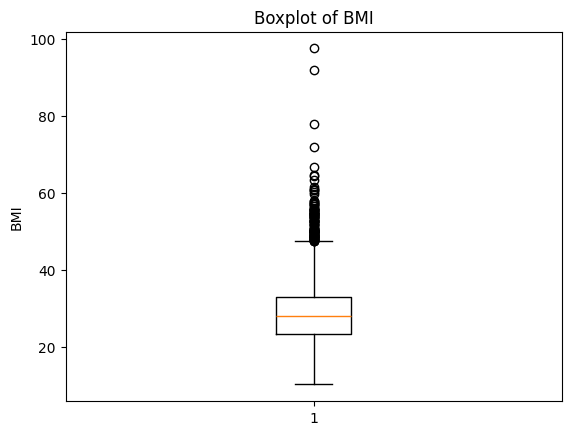

In [9]:
plt.figure()
plt.boxplot(df["bmi"].dropna())
plt.title("Boxplot of BMI")
plt.ylabel("BMI")
plt.show()

From the results above, we observe that 201 BMI values are missing, corresponding to 3.93% of the dataset. Given the relatively low proportion of missing data and the importance of preserving rare stroke cases in an already imbalanced dataset as observed later on, we decided not to remove these observations.

Instead, median imputation was applied to handle the missing BMI values. The median was chosen over the mean due to the presence of outliers in the BMI distribution as seen from the graph, making it a more robust measure of central tendency.

To maintain data integrity and allow for potential future analysis of missingness patterns, the imputed values were stored in a new variable (bmi_new), while the original BMI column was retained. This approach ensures transparency and preserves the possibility of investigating whether missing BMI values carry predictive information.

In [10]:
bmi_median = df["bmi"].median()
print("Median BMI:", bmi_median)

Median BMI: 28.1


In [11]:
# adding the new column
df["bmi_new"] = df["bmi"].fillna(bmi_median)

In [12]:
print(df.dtypes)

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
bmi_new              float64
dtype: object


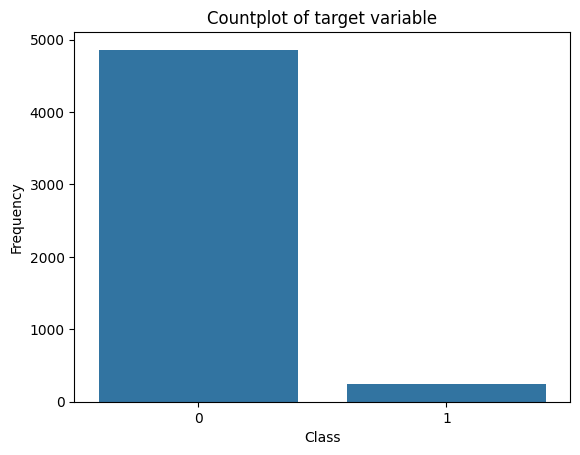

In [13]:
fig, ax = plt.subplots()
sns.countplot(data=df, x='stroke')
ax.set_title("Countplot of target variable")
ax.set_xlabel("Class")
ax.set_ylabel("Frequency")
plt.show()

The plot clearly indicates that the dataset is imbalanced, as the number of observations in each class is not evenly distributed. Specifically, the proportion of patients who experienced a stroke (class 1) is substantially lower compared to those who did not experience a stroke (class 0). This class imbalance should be taken into consideration during model development and evaluation, as it may bias the model toward the majority class.

In [14]:
sum_stroke = df["stroke"].sum()
count = df["stroke"].count()

percentage = (sum_stroke / count) * 100

print(f"Total stroke cases: {sum_stroke}")
print(f"Total patients: {count}")
print(f"Stroke percentage: {percentage:.2f}%")

Total stroke cases: 249
Total patients: 5110
Stroke percentage: 4.87%


The dataset contains 249 stroke cases out of 5110 patients.

Therefore, in subsequent stages of model development, appropriate resampling techniques such as SMOTE or random oversampling/undersampling will be considered to balance the class distribution and improve predictive performance, particularly for the minority class.
Also, we will consider other metrics like F1-score, Precision, Recall instead of just accuracy.


# Categorical Features Analysis

In [15]:
def pivot_feature(
    df: pd.DataFrame,
    feature: str,
    filter_col: str | None = None,
    filter_val = None,
    sort_index: bool = True,
    format_percent: bool = True
) -> pd.DataFrame:

    # optional filter (e.g. stroke == 1)
    data = df
    if filter_col is not None:
        data = data[data[filter_col] == filter_val]

    # counts per category (including NaN as its own row)
    counts = data[feature].value_counts(dropna=False)

    # percentage of total
    perc = counts / counts.sum() * 100

    if format_percent:
        volume_pct = perc.round(1).astype(str) + "%"
    else:
        volume_pct = perc

    out = pd.DataFrame({
        "Total Count": counts,
        "Volume Percentage": volume_pct
    })

    if sort_index:
        out = out.sort_index()

    return out

Below, a detailed breakdown per feature is presented to analyze the distribution across groups. This allows us to identify any categories that may require filtering or consolidation and to assess whether the distribution of features differs between the overall patient population and the subset of patients who experienced a stroke (stroke = 1) represented in a pivot table format below. Such comparisons help detect potential imbalances, sparse categories, or patterns that may be clinically and predictively relevant.

In [16]:
# Example: gender distribution among stroke patients
print(pivot_feature(df,"gender"))
print(pivot_feature(df, "gender", filter_col="stroke", filter_val=1))

        Total Count Volume Percentage
gender                               
Female         2994             58.6%
Male           2115             41.4%
Other             1              0.0%
        Total Count Volume Percentage
gender                               
Female          141             56.6%
Male            108             43.4%


From the results, we observe that only one patient is classified under the category “Other” in the gender variable. Moreover, this category is not represented among patients who experienced a stroke (stroke = 1). Since it accounts for a single observation and does not contribute to the positive class, its impact on the overall analysis is negligible. In contrast, the distribution between male and female patients appears relatively balanced, reducing concerns about gender-related sampling bias. Therefore, excluding the single “Other” observation is unlikely to affect the dataset’s statistical integrity and can reasonably be performed to avoid sparsity issues during modeling.

In [17]:
df = df[df["gender"] != "Other"]
print(df["gender"].value_counts())

gender
Female    2994
Male      2115
Name: count, dtype: int64


In [18]:
print(pivot_feature(df,"hypertension"))
print(pivot_feature(df, "hypertension", filter_col="stroke", filter_val=1))

              Total Count Volume Percentage
hypertension                               
0                    4611             90.3%
1                     498              9.7%
              Total Count Volume Percentage
hypertension                               
0                     183             73.5%
1                      66             26.5%


The analysis reveals a notable difference in hypertension prevalence between the overall dataset and the stroke subgroup. In the total population, 9.7% of patients have hypertension, while 90.3% do not. However, among patients who experienced a stroke (stroke = 1), 26.5% have hypertension, compared to 73.5% without hypertension.

This indicates that hypertension is substantially more prevalent among stroke patients than in the general study population (26.5% vs 9.7%). The nearly x3 increase suggests a strong association between hypertension and stroke occurrence.

Therefore, these findings indicate hypertension as an important predictive feature in subsequent modeling stages.

In [19]:
print(pivot_feature(df,"heart_disease"))
print(pivot_feature(df, "heart_disease", filter_col="stroke", filter_val=1))

               Total Count Volume Percentage
heart_disease                               
0                     4833             94.6%
1                      276              5.4%
               Total Count Volume Percentage
heart_disease                               
0                      202             81.1%
1                       47             18.9%


A similar pattern is observed for heart disease. While only 5.4% of the overall population has heart disease, its prevalence increases to 18.9% among stroke patients. This substantial difference suggests a strong association between heart disease and stroke occurrence, supporting its importance as a predictive feature in the model.

In [20]:
print(pivot_feature(df,"ever_married"))
print(pivot_feature(df, "ever_married", filter_col="stroke", filter_val=1))

              Total Count Volume Percentage
ever_married                               
No                   1756             34.4%
Yes                  3353             65.6%
              Total Count Volume Percentage
ever_married                               
No                     29             11.6%
Yes                   220             88.4%


In the overall dataset, 65.6% of patients are married, while 34.4% are not. However, among stroke patients, 88.4% are married compared to only 11.6% who are unmarried. This marked difference suggests a strong association between marital status and stroke occurrence within the dataset.

Nevertheless, this relationship may be influenced by age, as older individuals are more likely to be married and also at higher risk of stroke. Therefore, further multivariate analysis is required to determine whether marital status independently contributes to stroke prediction.

In [21]:
print("Age per group of the whole dataset:")
print(df.groupby("ever_married")["age"].mean())
print()
print("Age per group of the Stroke = 1 subaset:")
print(df[df["stroke"] == 1].groupby("ever_married")["age"].mean())

Age per group of the whole dataset:
ever_married
No     22.011959
Yes    54.342082
Name: age, dtype: float64

Age per group of the Stroke = 1 subaset:
ever_married
No     65.355862
Yes    68.040909
Name: age, dtype: float64


The mean age of married patients in the overall dataset (54.3 years) is substantially higher than that of unmarried patients (22.0 years), indicating a strong association between marital status and age. Given that age is a major risk factor for stroke, this suggests potential confounding.

Within the stroke subgroup, the mean ages of married (68.0 years) and unmarried (65.4 years) patients are much closer, indicating that the observed higher proportion of married stroke patients is likely driven by age rather than marital status independently.

Therefore, marital status may not represent an independent risk factor.

In [22]:
print("Value Counts of work_type feature before mapping restructuring:")
print(df["work_type"].value_counts())
print()

work_map = {
    "Govt_job": "Working",
    "Private": "Working",
    "Self-employed": "Working",
    "children": "Children",
    "Never_worked": "Not_working"
}
df["work_grouped"] = df["work_type"].map(work_map)

print("Value Counts of work_type feature after mapping restructuring:")
print(df["work_grouped"].value_counts())

Value Counts of work_type feature before mapping restructuring:
work_type
Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Value Counts of work_type feature after mapping restructuring:
work_grouped
Working        4400
Children        687
Not_working      22
Name: count, dtype: int64


In [23]:
print(pivot_feature(df,"work_grouped"))
print(pivot_feature(df, "work_grouped", filter_col="stroke", filter_val=1))
# df.head()

              Total Count Volume Percentage
work_grouped                               
Children              687             13.4%
Not_working            22              0.4%
Working              4400             86.1%
              Total Count Volume Percentage
work_grouped                               
Children                2              0.8%
Working               247             99.2%


In [24]:
from IPython.display import display, Markdown

display(Markdown("**MEAN age per Work Category:**"))
print("Age per group of the whole dataset:")
print(df.groupby("work_grouped")["age"].mean())
print()
print("Age per group of the Stroke = 1 subaset:")
print(df[df["stroke"] == 1].groupby("work_grouped")["age"].mean())
print()
display(Markdown("**MAX age per Work Category:**"))
print("Age per group of the whole dataset:")
print(df.groupby("work_grouped")["age"].max())
print()
print("Age per group of the Stroke = 1 subaset:")
print(df[df["stroke"] == 1].groupby("work_grouped")["age"].max())

**MEAN age per Work Category:**

Age per group of the whole dataset:
work_grouped
Children        6.841339
Not_working    16.181818
Working        49.046818
Name: age, dtype: float64

Age per group of the Stroke = 1 subaset:
work_grouped
Children     7.660000
Working     68.214575
Name: age, dtype: float64



**MAX age per Work Category:**

Age per group of the whole dataset:
work_grouped
Children       16.0
Not_working    23.0
Working        82.0
Name: age, dtype: float64

Age per group of the Stroke = 1 subaset:
work_grouped
Children    14.0
Working     82.0
Name: age, dtype: float64


After restructuring the work categories, 86.1% of the overall population falls under the “Working” group, 13.4% are classified as “Children,” and only 0.4% as “Not working.” Among stroke patients, 99.2% belong to the “Working” category, while 0.8% are classified as “Children,” and none fall under “Not working.”

The near absence of stroke cases in the “Children” and “Not working” groups is likely attributable to age. The mean age in the overall dataset is 6.8 years for Children and 16.2 years for Not working, compared to 49.0 years for the Working group. Similarly, within the stroke subgroup, the Working group has a markedly higher mean age (68.2 years). Given that stroke predominantly affects older individuals, the observed association between work status and stroke appears age-driven rather than indicative of an independent occupational effect.

In [25]:
print(pivot_feature(df,"Residence_type"))
print(pivot_feature(df, "Residence_type", filter_col="stroke", filter_val=1))

                Total Count Volume Percentage
Residence_type                               
Rural                  2513             49.2%
Urban                  2596             50.8%
                Total Count Volume Percentage
Residence_type                               
Rural                   114             45.8%
Urban                   135             54.2%


The distribution of residence type appears balanced in both the overall dataset and the stroke subgroup, suggesting no evident association between residence (urban vs rural) and stroke occurrence in this population.

In [26]:
print(pivot_feature(df,"smoking_status"))
print(pivot_feature(df, "smoking_status", filter_col="stroke", filter_val=1))

                 Total Count Volume Percentage
smoking_status                                
Unknown                 1544             30.2%
formerly smoked          884             17.3%
never smoked            1892             37.0%
smokes                   789             15.4%
                 Total Count Volume Percentage
smoking_status                                
Unknown                   47             18.9%
formerly smoked           70             28.1%
never smoked              90             36.1%
smokes                    42             16.9%


Smoking status shows some variation between the overall dataset and the stroke subgroup, with a relatively higher proportion of former smokers among stroke patients. However, the overall distribution remains broadly similar across groups, suggesting that while smoking history may be relevant, further statistical analysis is required to determine its independent predictive value.

In [27]:
pd.crosstab(df["smoking_status"], df["stroke"], normalize="index") * 100

stroke,0,1
smoking_status,,
Unknown,96.955959,3.044041
formerly smoked,92.081448,7.918552
never smoked,95.243129,4.756871
smokes,94.676806,5.323194


In [28]:
display(Markdown("**MEAN age per Work Category:**"))
print("Age per group of the whole dataset:")
print(df.groupby("smoking_status")["age"].mean())
print()
print("Age per group of the Stroke = 1 subaset:")
print(df[df["stroke"] == 1].groupby("smoking_status")["age"].mean())

**MEAN age per Work Category:**

Age per group of the whole dataset:
smoking_status
Unknown            30.229922
formerly smoked    54.962670
never smoked       46.744715
smokes             47.096324
Name: age, dtype: float64

Age per group of the Stroke = 1 subaset:
smoking_status
Unknown            65.836596
formerly smoked    68.628571
never smoked       70.311111
smokes             62.809524
Name: age, dtype: float64


Hence, the above analysis suggests a higher stroke prevalence among former and current smokers. However, further examination shows that all groups where "Stroke=1" have a substantially higher mean age, indicating that the observed association is likely confounded by age. Given the strong independent effect of age on stroke risk, smoking status does not appear to be a primary driver of stroke occurrence in this dataset.

For methodological flexibility, an additional binary variable (ever_smoked and never_smoked) will be created to consolidate smoking history, allowing its potential relevance to be reassessed during later modeling and resampling stages if required.

In [29]:
print("Value Counts of smoking_status feature before mapping restructuring:")
print(df["smoking_status"].value_counts())
print()

work_map = {
    "Unknown": "Unknown",
    "formerly smoked": "Ever_Smoked",
    "never smoked": "Never_Smoked",
    "smokes": "Ever_Smoked"
}
df["smoking_status_grouped"] = df["smoking_status"].map(work_map)

print("Value Counts of smoking_status feature after mapping restructuring:")
print(df["smoking_status_grouped"].value_counts())

Value Counts of smoking_status feature before mapping restructuring:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64

Value Counts of smoking_status feature after mapping restructuring:
smoking_status_grouped
Never_Smoked    1892
Ever_Smoked     1673
Unknown         1544
Name: count, dtype: int64


In [30]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke', 'bmi_new', 'work_grouped',
       'smoking_status_grouped'],
      dtype='object')

In [31]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_new,work_grouped,smoking_status_grouped
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,36.6,Working,Ever_Smoked
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,28.1,Working,Never_Smoked
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,32.5,Working,Never_Smoked
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,34.4,Working,Ever_Smoked
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,24.0,Working,Never_Smoked


# Numerical Features Analysis/Reconstructing

The BMI variable has already been explored and a new feature (bmi_new) was generated following median imputation. Additionally, age has been identified as a significant predictor of stroke. The next step is to examine the avg_glucose_level variable in greater detail.

To further enhance our understanding of the data, continuous variables such as age and average glucose level will be grouped into clinically meaningful ranges. This stratification will allow us to better assess their distribution across stroke and non-stroke cases and to identify which specific value ranges are more strongly associated with stroke occurrence.

In [32]:
print(df[["age", "avg_glucose_level", "bmi", "bmi_new"]].describe())

               age  avg_glucose_level         bmi      bmi_new
count  5109.000000        5109.000000  4908.00000  5109.000000
mean     43.229986         106.140399    28.89456    28.863300
std      22.613575          45.285004     7.85432     7.699785
min       0.080000          55.120000    10.30000    10.300000
25%      25.000000          77.240000    23.50000    23.800000
50%      45.000000          91.880000    28.10000    28.100000
75%      61.000000         114.090000    33.10000    32.800000
max      82.000000         271.740000    97.60000    97.600000


In [33]:
bins_age = [0, 30, 45, 60, 75, 85]
labels_age = ['0-29', '30-44', '45-59', '60-74', '75+']

df['age_bin'] = pd.cut(df['age'], bins=bins_age, labels=labels_age, right=False)

In [34]:
bins_glucose = [0, 90, 125, 200, 300]
labels_glucose = ['Normal', 'Prediabetic', 'Diabetic', 'Severely High']

df['glucose_bin'] = pd.cut(df['avg_glucose_level'],
                           bins=bins_glucose,
                           labels=labels_glucose,
                           right=False)

In [35]:
bins_bmi = [0, 18.5, 25, 30, 35, 100]
labels_bmi = ['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II+']

df['bmi_bin'] = pd.cut(df['bmi_new'],
                       bins=bins_bmi,
                       labels=labels_bmi,
                       right=False)

In [36]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke', 'bmi_new', 'work_grouped',
       'smoking_status_grouped', 'age_bin', 'glucose_bin', 'bmi_bin'],
      dtype='object')

Before proceeding with further analysis, the continuous variables were grouped into clinically meaningful categories to improve interpretability and facilitate subgroup comparison.

## Age

* Binned according to distribution quartiles and clinically relevant risk thresholds.
* Enables clearer visualization of stroke prevalence across life stages.

## Average Glucose Level

* Categorized based on clinical glycemic ranges (normal, prediabetic, diabetic, severely high).
* Aligns with established medical thresholds for metabolic risk.
* Facilitates assessment of stroke distribution across metabolic status groups.

## BMI (bmi_new)

* Grouped using standard clinical classifications (underweight, normal, overweight, obese).
* Allows evaluation of stroke prevalence across weight categories.

These categorizations enhance exploratory analysis by improving interpretability while preserving the option to use continuous variables in subsequent multivariate modeling.

In [37]:
print(pivot_feature(df,"age_bin"))
print(pivot_feature(df, "age_bin", filter_col="stroke", filter_val=1))

print()
print(pd.crosstab(df['age_bin'], df['stroke'], normalize='index') * 100)

         Total Count Volume Percentage
age_bin                               
0-29            1514             29.6%
30-44           1018             19.9%
45-59           1201             23.5%
60-74            858             16.8%
75+              518             10.1%
         Total Count Volume Percentage
age_bin                               
0-29               2              0.8%
30-44              8              3.2%
45-59             58             23.3%
60-74             79             31.7%
75+              102             41.0%

stroke           0          1
age_bin                      
0-29     99.867900   0.132100
30-44    99.214145   0.785855
45-59    95.170691   4.829309
60-74    90.792541   9.207459
75+      80.308880  19.691120


The analysis demonstrates a clear and progressive increase in stroke prevalence with advancing age. While stroke cases are rare in individuals under 45 years, the proportion rises substantially in older age groups, reaching its highest level in patients aged 75 and above.

This strong gradient insists age as one of the most influential risk factor in the dataset and a primary driver of stroke occurrence.

In [38]:
print(pivot_feature(df,"glucose_bin"))
print(pivot_feature(df, "glucose_bin", filter_col="stroke", filter_val=1))

print()
print(pd.crosstab(df['glucose_bin'], df['stroke'], normalize='index') * 100)

               Total Count Volume Percentage
glucose_bin                                 
Normal                2402             47.0%
Prediabetic           1708             33.4%
Diabetic               565             11.1%
Severely High          434              8.5%
               Total Count Volume Percentage
glucose_bin                                 
Normal                  88             35.3%
Prediabetic             61             24.5%
Diabetic                44             17.7%
Severely High           56             22.5%

stroke                 0          1
glucose_bin                        
Normal         96.336386   3.663614
Prediabetic    96.428571   3.571429
Diabetic       92.212389   7.787611
Severely High  87.096774  12.903226


The analysis reveals a clear increase in stroke prevalence with rising glucose levels.

While individuals in the normal and prediabetic ranges exhibit relatively low stroke proportions, the rate increases notably in the diabetic and severely high glucose groups. This progressive trend suggests that elevated glucose levels are positively associated with stroke occurrence and may represent an important metabolic risk factor within the dataset

In [39]:
print(pivot_feature(df,"bmi_bin"))
print(pivot_feature(df, "bmi_bin", filter_col="stroke", filter_val=1))

print()
print(pd.crosstab(df['bmi_bin'], df['stroke'], normalize='index') * 100)

             Total Count Volume Percentage
bmi_bin                                   
Underweight          337              6.6%
Normal              1242             24.3%
Overweight          1610             31.5%
Obese I             1000             19.6%
Obese II+            920             18.0%
             Total Count Volume Percentage
bmi_bin                                   
Underweight            1              0.4%
Normal                35             14.1%
Overweight           115             46.2%
Obese I               56             22.5%
Obese II+             42             16.9%

stroke               0         1
bmi_bin                         
Underweight  99.703264  0.296736
Normal       97.181965  2.818035
Overweight   92.857143  7.142857
Obese I      94.400000  5.600000
Obese II+    95.434783  4.565217


In [40]:
display(Markdown("**MEAN age per bmi Category:**"))
print("Age per group of the whole dataset:")
print(df.groupby("bmi_bin", observed=False)["age"].mean())
print()
print("Age per group of the Stroke = 1 subaset:")
print(df[df["stroke"] == 1].groupby("bmi_bin", observed=False)["age"].mean())

**MEAN age per bmi Category:**

Age per group of the whole dataset:
bmi_bin
Underweight    10.908843
Normal         33.762512
Overweight     49.501168
Obese I        51.766800
Obese II+      47.596739
Name: age, dtype: float64

Age per group of the Stroke = 1 subaset:
bmi_bin
Underweight    81.000000
Normal         74.000000
Overweight     68.115826
Obese I        67.303571
Obese II+      61.690476
Name: age, dtype: float64


When combining the BMI distribution and mean age analysis, it becomes evident that age remains the dominant factor influencing stroke occurrence.

The overweight and obese categories are concentrated in older age groups, and stroke cases within each BMI category also occur predominantly at advanced ages. This suggests that the higher stroke proportion observed in overweight individuals is largely age-driven.

Nevertheless, elevated BMI may still act as a contributing cardiovascular risk factor and should be considered as a potential additive effect in multivariate modeling.

# Overall Findings

## Dataset Modifications and Pre-Processing Decisions

Following initial inspection, minor structural edits were applied to improve dataset consistency.

* One observation belonging to 'Other' gender category was removed due to sparsity and lack of representation in the positive class.
* A new variable (bmi_new) was created using median imputation to address missing BMI values while preserving all patient records.
* Categorical variables were regrouped into clinically meaningful subcategories to reduce dimensionality and improve interpretability during analysis.

Hence, after these adjustments, the dataset consists of 5,109 observations and an expanded feature set reflecting the engineered variables.

No duplicate records, logical inconsistencies, or zero-value errors were identified. At this stage, no outlier removal has been performed in order to avoid eliminating clinically extreme but potentially important cases. Stating that, we could propose performing a Z-score thresholding
which would remove or cap values beyond ±3 standard deviations.

## Class Imbalance and Planned Handling Strategy

The dataset remains strongly imbalanced in its binary classification structure, with stroke cases representing a small minority of observations. Because of this imbalance, standard training without correction would bias predictions toward the majority class.

To improve minority class detection and obtain more reliable results, the following strategy is proposed:

Apply SMOTE to the training data to synthetically generate minority class examples.

Evaluate models using recall, F1-score, and ROC-AUC, rather than accuracy alone.

SMOTE is preferred over simple random oversampling because it generates synthetic samples rather than duplicating existing ones, reducing overfitting risk while improving class representation.

In [41]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# --- VERSION 1: BASELINE ---
# Numerical values with minimal encoding
df_v1 = df.copy()
le = LabelEncoder()
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    df_v1[col] = le.fit_transform(df_v1[col])
print("V1 Visualisation")
print(df_v1.head())
print()

# --- VERSION 2: CLINICAL-CATEGORICAL ---
# Focuses on the binned categories you created for better interpretability
cols_to_keep = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                'work_grouped', 'Residence_type', 'smoking_status_grouped',
                'age_bin', 'glucose_bin', 'bmi_bin', 'stroke']
df_v2 = pd.get_dummies(df[cols_to_keep], drop_first=True)
print("V2 Visualisation")
print(df_v2.head())
print()

# --- VERSION 3: SCALED & SMOTE ---
# Standardized continuous variables and balanced classes for ML optimization
df_v3_temp = df_v1.drop(columns=['id', 'bmi', 'work_grouped', 'smoking_status_grouped', 'age_bin', 'glucose_bin', 'bmi_bin'])
scaler = StandardScaler()
num_cols = ['age', 'avg_glucose_level', 'bmi_new']
df_v3_temp[num_cols] = scaler.fit_transform(df_v3_temp[num_cols])

X = df_v3_temp.drop('stroke', axis=1)
y = df_v3_temp['stroke']
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
df_v3 = pd.concat([pd.DataFrame(X_res), pd.DataFrame(y_res, columns=['stroke'])], axis=1)
print("V3 Visualisation")
print(df_v3.head())
print()

# --- VERSION 4: FEATURE REDUCED ---
# Removing 'Residence_type' and 'ever_married' based on your confounding analysis
df_v4 = df_v3.drop(columns=['Residence_type', 'ever_married'], errors='ignore')
print("V4 Visualisation")
print(df_v4.head())
print()

print("All four dataset versions have been generated successfully.")

V1 Visualisation
      id  gender   age  hypertension  heart_disease  ever_married  work_type  \
0   9046       1  67.0             0              1             1          2   
1  51676       0  61.0             0              0             1          3   
2  31112       1  80.0             0              1             1          2   
3  60182       0  49.0             0              0             1          2   
4   1665       0  79.0             1              0             1          3   

   Residence_type  avg_glucose_level   bmi  smoking_status  stroke  bmi_new  \
0               1             228.69  36.6               1       1     36.6   
1               0             202.21   NaN               2       1     28.1   
2               0             105.92  32.5               2       1     32.5   
3               1             171.23  34.4               3       1     34.4   
4               0             174.12  24.0               2       1     24.0   

  work_grouped smoking_stat

**Summary of the Versions:**

* V1 (Baseline): Uses original numerical values and basic label encoding for categories.
* V2 (Categorical): Converts your clinical bins (Age, Glucose, BMI) into dummy variables, prioritizing interpretability.
* V3 (Optimized): Applies Standardization to continuous features and uses SMOTE to fix the 4.87% class imbalance.
* V4 (Expert-Knowledge): Removes features like ever_married which your analysis showed were largely confounded by age.

In [42]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# 1. Load the pre-processed dataset
# Using the version optimized with SMOTE and Scaling
X = df_v3.drop('stroke', axis=1)
y = df_v3['stroke']

# 2. Define the cross-validation strategy
# StratifiedKFold ensures the 4.87% stroke class is represented in every fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Initialize models with updated parameters
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric='logloss', # Specified to avoid warnings in newer versions
        random_state=42
    )
}

# 4. Define evaluation metrics (Focusing on Recall and F1 for medical diagnosis)
scoring = ['recall', 'f1', 'roc_auc', 'precision']

# 5. Execute and Display Results
print(f"{'Model':<20} | {'Recall':<10} | {'F1-Score':<10} | {'ROC-AUC':<10}")
print("-" * 60)

for name, model in models.items():
    # Performance evaluation across 5 folds
    scores = cross_validate(model, X, y, cv=cv_strategy, scoring=scoring)

    print(f"{name:<20} | "
          f"{np.mean(scores['test_recall']):.4f}     | "
          f"{np.mean(scores['test_f1']):.4f}       | "
          f"{np.mean(scores['test_roc_auc']):.4f}")

X = df_v2.drop('stroke', axis=1)
y = df_v2['stroke']
for name, model in models.items():
    # Performance evaluation across 5 folds
    scores = cross_validate(model, X, y, cv=cv_strategy, scoring=scoring)

    print(f"{name:<20} | "
          f"{np.mean(scores['test_recall']):.4f}     | "
          f"{np.mean(scores['test_f1']):.4f}       | "
          f"{np.mean(scores['test_roc_auc']):.4f}")

X = df_v4.drop('stroke', axis=1)
y = df_v4['stroke']
for name, model in models.items():
    # Performance evaluation across 5 folds
    scores = cross_validate(model, X, y, cv=cv_strategy, scoring=scoring)

    print(f"{name:<20} | "
          f"{np.mean(scores['test_recall']):.4f}     | "
          f"{np.mean(scores['test_f1']):.4f}       | "
          f"{np.mean(scores['test_roc_auc']):.4f}")

Model                | Recall     | F1-Score   | ROC-AUC   
------------------------------------------------------------
Logistic Regression  | 0.8243     | 0.7936       | 0.8605
Random Forest        | 0.9636     | 0.9363       | 0.9850
SVM                  | 0.9045     | 0.8421       | 0.9038
XGBoost              | 0.9500     | 0.9325       | 0.9850


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

Logistic Regression  | 0.0000     | 0.0000       | 0.8281
Random Forest        | 0.0162     | 0.0238       | 0.7116


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

SVM                  | 0.0000     | 0.0000       | 0.6808
XGBoost              | 0.0322     | 0.0453       | 0.7538
Logistic Regression  | 0.8200     | 0.7887       | 0.8562
Random Forest        | 0.9570     | 0.9310       | 0.9802
SVM                  | 0.9012     | 0.8357       | 0.8960
XGBoost              | 0.9467     | 0.9321       | 0.9836


Across the three dataset, Random Forest consistently demonstrates the strongest and most stable performance, especially on the SMOTE-balanced datasets (v3 and v4). In v3 and v4, it achieves the highest Recall (0.9636 and 0.9570), highest F1-Score (0.9363 and 0.9310), and near-perfect ROC-AUC (0.9850 and 0.9802), indicating excellent ability to detect stroke cases while maintaining a strong balance between precision and recall. Although XGBoost performs very closely, Random Forest slightly outperforms it in Recall and F1-Score. In contrast, all models perform extremely poorly on the imbalanced dataset (v2), with near-zero Recall, highlighting the importance of SMOTE for medical diagnosis tasks. Therefore, Random Forest trained on the balanced dataset (v3) is the best overall model due to its superior predictive power and consistency.

In [43]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

scoring = ['recall', 'f1', 'roc_auc', 'precision']

results = []

# Clean V1 only for experimentation
cols_v1 = [
    'gender', 'age', 'hypertension', 'heart_disease',
    'ever_married', 'work_type', 'Residence_type',
    'avg_glucose_level', 'bmi_new', 'smoking_status',
    'stroke'
]

df_v1_exp = df_v1[cols_v1].copy()

datasets = {
    'V1': df_v1_exp,
    'V2': df_v2,
    'V3': df_v3,
    'V4': df_v4
}

print(f"{'Dataset':<8} | {'Model':<20} | {'Recall':<10} | {'F1-Score':<10} | {'ROC-AUC':<10}")
print("-" * 80)

for dname, dframe in datasets.items():
    X = dframe.drop('stroke', axis=1)
    y = dframe['stroke']

    for name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv_strategy, scoring=scoring)

        recall_mean = np.mean(scores['test_recall'])
        f1_mean = np.mean(scores['test_f1'])
        roc_mean = np.mean(scores['test_roc_auc'])
        precision_mean = np.mean(scores['test_precision'])

        results.append({
            'Dataset': dname,
            'Model': name,
            'Recall': recall_mean,
            'F1': f1_mean,
            'ROC_AUC': roc_mean,
            'Precision': precision_mean
        })

        print(f"{dname:<8} | {name:<20} | {recall_mean:.4f}     | {f1_mean:.4f}       | {roc_mean:.4f}")

Dataset  | Model                | Recall     | F1-Score   | ROC-AUC   
--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

V1       | Logistic Regression  | 0.0000     | 0.0000       | 0.8375
V1       | Random Forest        | 0.0081     | 0.0154       | 0.8015


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

V1       | SVM                  | 0.0000     | 0.0000       | 0.6370
V1       | XGBoost              | 0.0725     | 0.1055       | 0.8045
V2       | Logistic Regression  | 0.0000     | 0.0000       | 0.8281


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

V2       | Random Forest        | 0.0162     | 0.0238       | 0.7116


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

V2       | SVM                  | 0.0000     | 0.0000       | 0.6808
V2       | XGBoost              | 0.0322     | 0.0453       | 0.7538
V3       | Logistic Regression  | 0.8243     | 0.7936       | 0.8605
V3       | Random Forest        | 0.9636     | 0.9363       | 0.9850
V3       | SVM                  | 0.9045     | 0.8421       | 0.9038
V3       | XGBoost              | 0.9500     | 0.9325       | 0.9850
V4       | Logistic Regression  | 0.8200     | 0.7887       | 0.8562
V4       | Random Forest        | 0.9570     | 0.9310       | 0.9802
V4       | SVM                  | 0.9012     | 0.8357       | 0.8960
V4       | XGBoost              | 0.9467     | 0.9321       | 0.9836


In [64]:
results_df = pd.DataFrame(results)
results_df['Overall_Score'] = results_df[['Recall', 'F1', 'ROC_AUC', 'Precision']].mean(axis=1)
results_df = results_df.sort_values(by=['Recall', 'F1', 'ROC_AUC'], ascending=False)

print("FINAL SORTED RESULTS TABLE")
print(results_df)

FINAL SORTED RESULTS TABLE
   Dataset                Model    Recall        F1   ROC_AUC  Precision  \
9       V3        Random Forest  0.963580  0.936318  0.984973   0.910578   
13      V4        Random Forest  0.956996  0.931038  0.980166   0.906471   
11      V3              XGBoost  0.950000  0.932526  0.985005   0.915821   
15      V4              XGBoost  0.946708  0.932068  0.983585   0.917954   
10      V3                  SVM  0.904527  0.842055  0.903763   0.787706   
14      V4                  SVM  0.901235  0.835719  0.896044   0.779165   
8       V3  Logistic Regression  0.824280  0.793627  0.860546   0.765265   
12      V4  Logistic Regression  0.819959  0.788673  0.856165   0.759828   
3       V1              XGBoost  0.072490  0.105505  0.804484   0.231146   
7       V2              XGBoost  0.032163  0.045307  0.753806   0.079095   
5       V2        Random Forest  0.016163  0.023828  0.711624   0.046437   
1       V1        Random Forest  0.008082  0.015385  0.801472

Based on the initial experiments, the best-performing models are Random
Forest and XGBoost, consistently achieving the highest Recall, F1-score, and ROC-AUC across the optimized datasets.

The most effective preprocessing techniques correspond to V3 (scaled + SMOTE) and V4 (feature-reduced + SMOTE), which significantly **improve Recall** compared to the baseline datasets.

This highlights the importance of handling class imbalance and applying appropriate feature engineering. Therefore, the combinations of Random Forest and XGBoost with V3/V4 datasets are selected for further pipeline development and hyperparameter tuning.

# Exploratory Data Analysis (EDA)
### Visual exploration of the Stroke Prediction Dataset

This section provides graphical analysis to understand:
- Class imbalance
- Feature distributions
- Relationships between features and stroke occurance
- Potential predictive patterns

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### Data Cleaning:


In [46]:
# Remove other gender row
df=df[df["gender"] != "Other"].copy()

#Create new BMI
bmi_median = df["bmi"].median()
df["bmi_new"] = df["bmi"].fillna(bmi_median)

print("Median BMI used:", bmi_median)
print("New shape:", df.shape)
print("Missing bmi:", df["bmi"].isna().sum())
print("Missing bmi_new:", df["bmi_new"].isna().sum())

Median BMI used: 28.1
New shape: (5109, 18)
Missing bmi: 201
Missing bmi_new: 0


### Target Class Distribution:


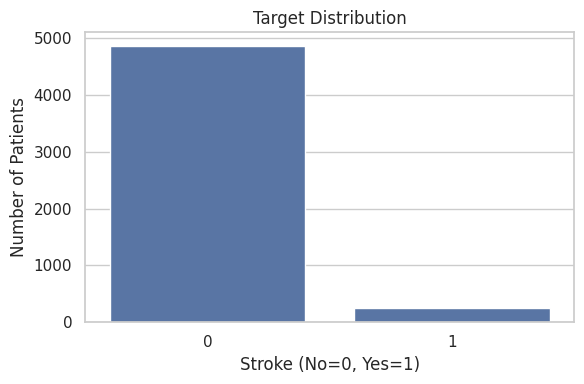

Stroke cases: 249
Total patient: 5109
Stroke percentage: 4.87%


In [47]:
#Target class distribution
plt.figure(figsize=(6,4))
sns.countplot(x="stroke", data=df)
plt.title("Target Distribution")
plt.xlabel("Stroke (No=0, Yes=1)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

#percentage
stroke_cases=df["stroke"].sum()
total_cases=len(df)
stroke_percentage=(stroke_cases/total_cases)*100

print(f"Stroke cases: {stroke_cases}")
print(f"Total patient: {total_cases}")
print(f"Stroke percentage: {stroke_percentage:.2f}%")

The target variable is highly imbalanced. Out of 5109 patients only 249 (4.87%) experience a stroke, while the vast majority belong to non-stroke class.


### Distribution of Categorical Features:


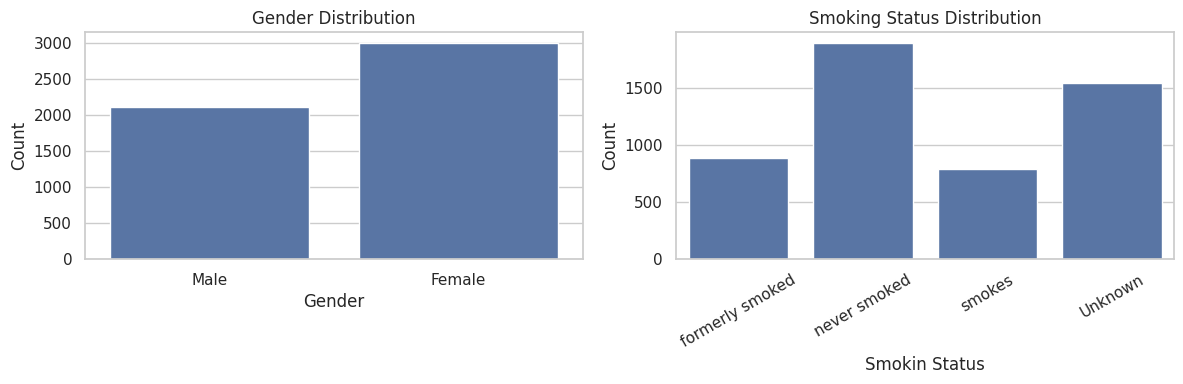

In [48]:
plt.figure(figsize=(12,4))

#Gender distribution
plt.subplot(1,2,1)
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

#Smoking status distribution
plt.subplot(1,2,2)
sns.countplot(x="smoking_status", data=df)
plt.title("Smoking Status Distribution")
plt.xlabel("Smokin Status")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

This analysis provides insight into the demographic and lifestyle characteristics of the dataset.
- The gender distribution shows that female patients slightly outnumber male patients in the dataset.
- The smoking status distribution indicates that most individuals have never smoked, while smaller groups include current smokers and former smokers. Additionally, a portion of the records is labeled as unknown, indicating missing or unspecified smoking information.


### Stroke Occurrence by Gender:


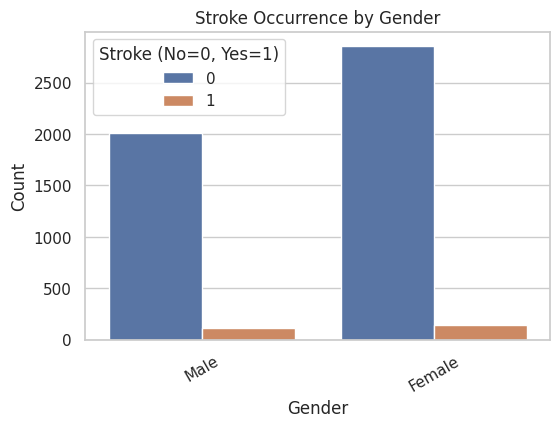

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender",hue="stroke", data=df)
plt.title("Stroke Occurrence by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Stroke (No=0, Yes=1)")
plt.show()

The comparison shows that bth male and female patients have stroke cases, although the majority of individuals in both groups did not exprerience a stroke. Female patients appear slightly more represented in the dataset overall, which explains the higher number of stroke cases among females. However, the difference between genders is relatively small, suggesting that gender alone may not be a strong predictor of stroke risk.


### Stroke Occurrence by Smoking Status:


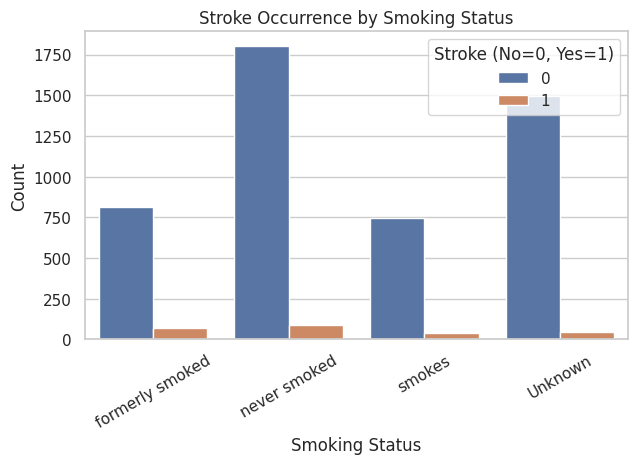

In [50]:
plt.figure(figsize=(7,4))
sns.countplot(x="smoking_status",hue="stroke", data=df)
plt.title("Stroke Occurrence by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Stroke (No=0, Yes=1)")
plt.show()

The plot shoes the distribution of stroke occurrence across different smoking categories. In all groups, non-stroke cases dominate due to the class imbalance in the dataset. However, stroke cases appear in multiple smoking categories, including individuals who never smoked and those who formerly smoked. Overall, smoking status may contribute to stroke risk but does not appear to be the strongest predictor.


### Distribution of Numerical Features:


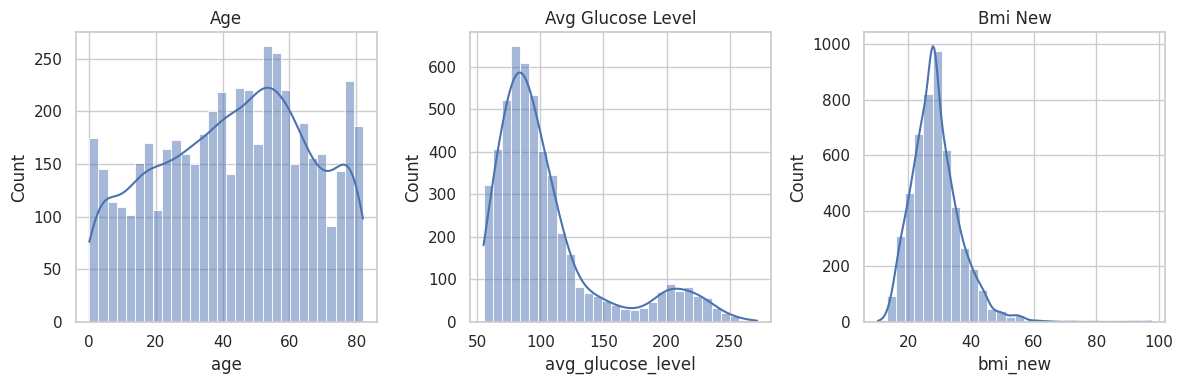

In [51]:
#Distribution of numerical features
numeric_features=["age", "avg_glucose_level", "bmi_new"]
plt.figure(figsize=(12,4))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(1,3,i)
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

The histograms show the distribution of the main numerical features in the dataset:
- **Age** is relatively well distributed across different age groups.
- The **average glucose level** shows a right skewed distribution, indicating that most patients have moderate glucose levels while a smaller number have very high values.
- The **BMI** distribution is concentrated around the 20s to 30s with a few higher values suggesting the presence of outliers.


### Boxplots of Numerical Features:


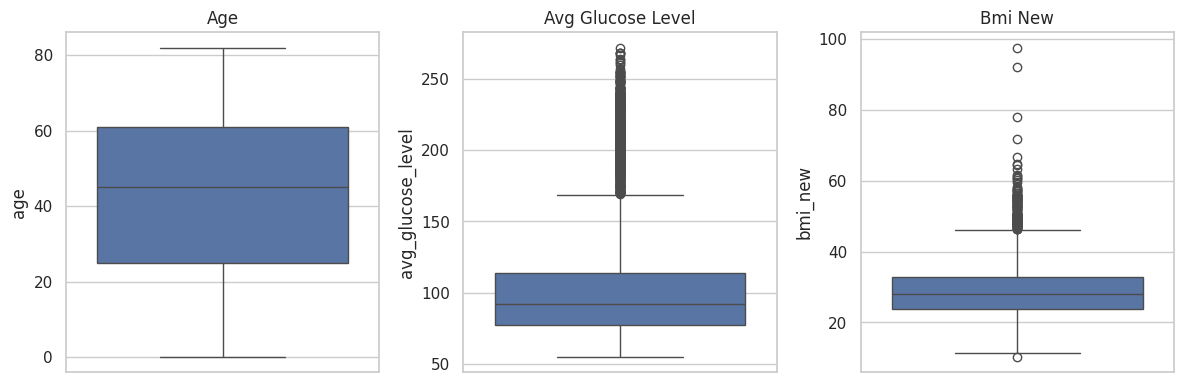

In [52]:
#Boxplots of numerical features
numeric_features=["age", "avg_glucose_level", "bmi_new"]
plt.figure(figsize=(12,4))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(1,3,i)
    sns.boxplot(y=df[feature])
    plt.title(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

The boxplots illustrate the spread and variability of the main numerical variables in the dataset.
- **Age** appears relativly evenly distributed without extreme outliers.
- Both **average glucose level** and **BMI** show several high-value outliers, indicating that some patients have unusually high measurements.

These extreme values may represent individuals with increase heallth risk and should be considered during further analysis and preprocessing.


### Age and Stroke Relationship:


#### Age Distribution by Stroke Outcome:


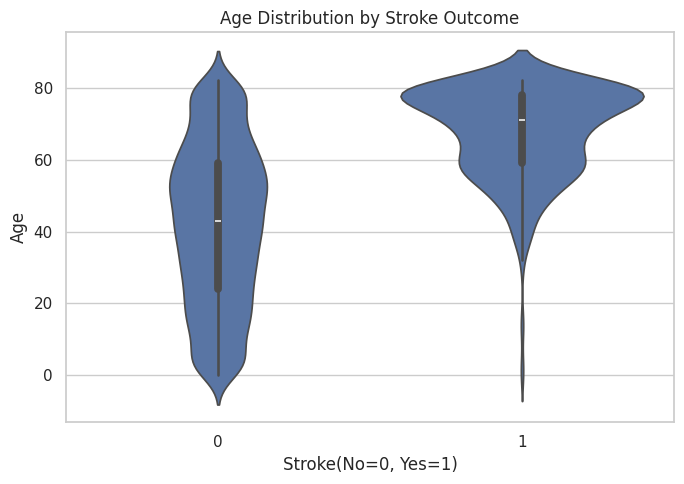

In [53]:
#Age vs Stroke
plt.figure(figsize=(7,5))
sns.violinplot(x="stroke", y="age", data=df)
plt.title("Age Distribution by Stroke Outcome")
plt.xlabel("Stroke(No=0, Yes=1)")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

The violin plot demonstrates a clear pattern in stroke occurrence. Patients who experienced a stroke are noticeably older with the distribution concentrated between 60 and 80 years old and a higher median age compare to the non-stroke group. On the other hand, the non-stroke class spans a much wider age range, including a number of younger individuals. Although some overlap exist between groups, age appears to be one of the most influential predictors in the dataset.


#### Stroke Rate Across Age Groups:


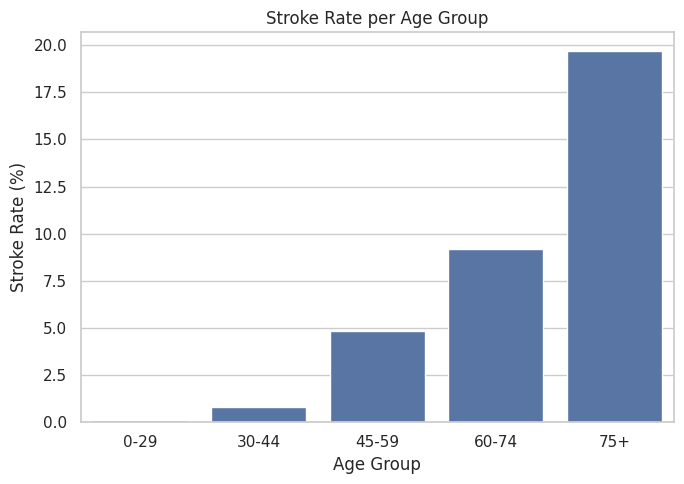

  Age Group  Stroke Rate (%)
0      0-29         0.132100
1     30-44         0.785855
2     45-59         4.829309
3     60-74         9.207459
4       75+        19.691120


In [54]:
#Stroke rate per age group
df["age_bin"]=pd.cut(df["age"],
                    bins=[0,30,45,60,75,85],
                    labels=["0-29", "30-44", "45-59", "60-74", "75+"],
                    right=False)

age_rate=(pd.crosstab(df["age_bin"], df["stroke"], normalize="index")*100)[1].reset_index()
age_rate.columns=["Age Group", "Stroke Rate (%)"]

plt.figure(figsize=(7,5))
sns.barplot(x="Age Group", y="Stroke Rate (%)", data=age_rate)
plt.title("Stroke Rate per Age Group")
plt.xlabel("Age Group")
plt.ylabel("Stroke Rate (%)")
plt.tight_layout()
plt.show()
print(age_rate)

The bar plot illustrates a clear and progressive increase in stroke prevelance with advancing age. Stroke rates are extremely low in individuals under 45 years old but rise substantially in older groups. Individuals aged 75 and older exhibit the highest stroke prevalence (19.7%), compared to only 0.13% in the age 0-29 group. This confirms age as one of the most influencial risk factors in the dataset and highlights its significant predictive importance.


### Stroke Rate by Glucose Level Category:


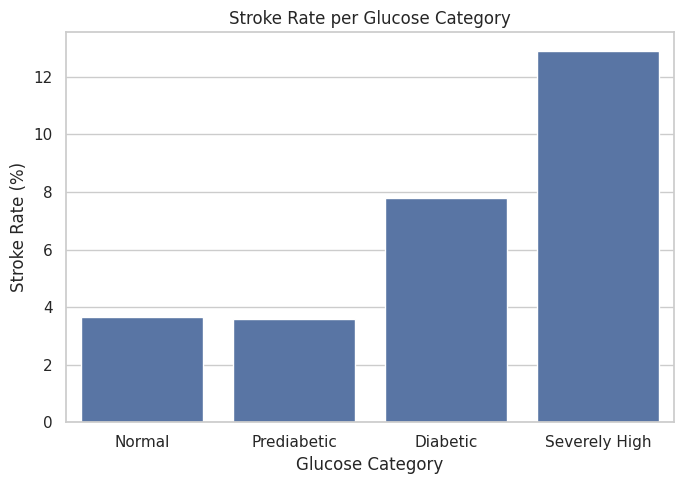

  Glucose Category  Stroke Rate (%)
0           Normal         3.663614
1      Prediabetic         3.571429
2         Diabetic         7.787611
3    Severely High        12.903226


In [55]:
#Glucose category stroke rate
df["glucose_bin"]=pd.cut(df["avg_glucose_level"],
                        bins=[0,90,125,200,300],
                        labels=["Normal", "Prediabetic", "Diabetic", "Severely High"],
                        right=False)

glucose_rate=(pd.crosstab(df["glucose_bin"], df["stroke"], normalize="index")*100)[1].reset_index()
glucose_rate.columns=["Glucose Category", "Stroke Rate (%)"]

plt.figure(figsize=(7,5))
sns.barplot(x="Glucose Category", y="Stroke Rate (%)", data=glucose_rate)
plt.title("Stroke Rate per Glucose Category")
plt.xlabel("Glucose Category")
plt.ylabel("Stroke Rate (%)")
plt.tight_layout()
plt.show()
print(glucose_rate)

The bar plot reveals a progressive increase in stroke prevalence with higher glucose rate. While individuals in the normal and prediabetic categories exhibit relatively similar an low stroke rates (around 3.6%), the rate nearly doubles in the diabetic group (7.8%) and rises further to approximately 12.9% in the severely high glucose category. This trend suggest a strong positive association between elevated glucose levels and stroke occurance.


### Stroke Rate by Hypertension Status:


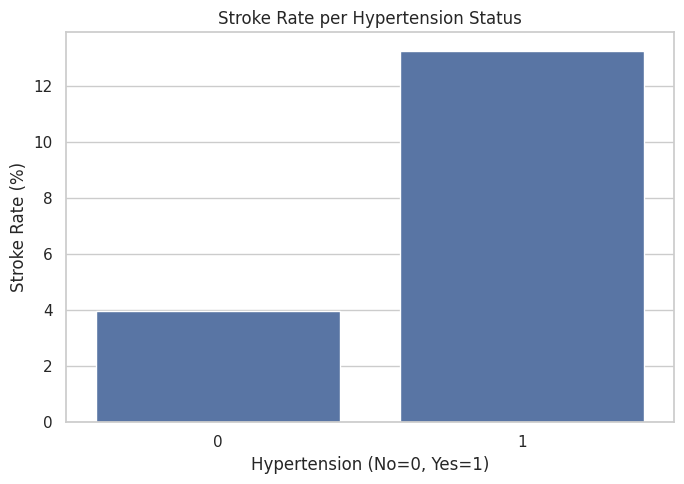

   Hypertension (No=0, Yes=1)  Stroke Rate (%)
0                           0         3.968770
1                           1        13.253012


In [56]:
# Hypertension vs Stroke rate
htn_rate=(pd.crosstab(df["hypertension"], df["stroke"], normalize="index")*100)[1].reset_index()
htn_rate.columns=["Hypertension (No=0, Yes=1)", "Stroke Rate (%)"]

plt.figure(figsize=(7,5))
sns.barplot(x="Hypertension (No=0, Yes=1)", y="Stroke Rate (%)", data=htn_rate)
plt.title("Stroke Rate per Hypertension Status")
plt.xlabel("Hypertension (No=0, Yes=1)")
plt.ylabel("Stroke Rate (%)")
plt.tight_layout()
plt.show()
print(htn_rate)

Patients with hypertension exhibit a substantially higher stroke prevalence (13.25%) compared to those without hypertansion (3.97%). This represents more than a threefold increase in stroke rate, supporting hypertansion as a significant risk factor within the dataset.


### Correlation Analysis of Numerical Features:


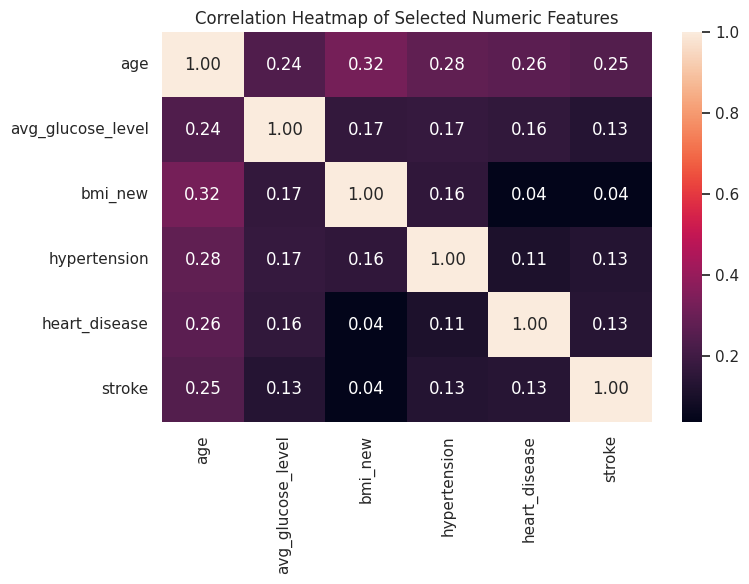

In [57]:
#Correlation Heatmap
numeric_cols=["age", "avg_glucose_level", "bmi_new", "hypertension", "heart_disease", "stroke"]
corr_matrix=df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Selected Numeric Features")
plt.tight_layout()
plt.show()

The correlation heatmap summarizes linear relationships among key numerical variables. Age demonstrates the strongest correlation with stroke (r=0.25), indicating its dominant predictive role. Hypertension, heart disease, and average glucose level exhibit moderate positive correlaions (r=0.13). BMI shows a week linear relationship with stoke (r=0.04), suggesting that its influence may be indirect or nonlinear.


### Pairwise Relationships Between Numerical Features:


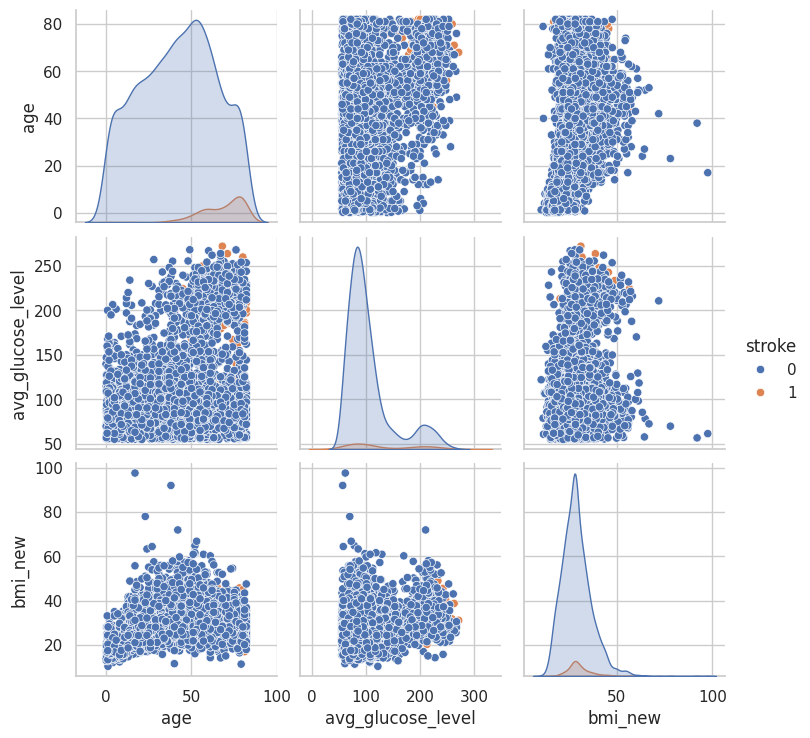

In [58]:
num_features=["age", "avg_glucose_level", "bmi_new", "stroke"]
sns.pairplot(df[num_features], hue="stroke")
plt.show()

The pairplot visualizes the relationship between the main numerical variables in the dataset (age, average glucose level, and BMI). the diagonical plots show the distribution of each feature, while the scatterplots illustrate pairwise relationships between variables.

Stroke cases appear mostly among older individuals, supporting earlier observations that age is strongly associated with stroke occurance. In contrast, BMI and average glucose level show weaker visual seperation between stroke and non-stroke groups. Overall, the visualization suggests that age is one of the most influential predictors in the dataset, while other variables may contribute in combination with additional risk factors.


### Key Findings:
The exploratory data analysis revealed several important patterns in the dataset.
- The target variable is highly imbalanced, with stroke cases representing only a small proportion of the total observations.
- Age appears to be the most influential factor, as stroke cases occur primarly among older individuals and the stroke rate increases significantly across higher age groups.
- Elevated glucose levels and hypertension are aslo associated with higher stroke prevalence.
- BMI and gender show weaker direct relationships with stoke occurance.

Overall, these findings highlight the importance of demographic and health related variables in predictive stroke.

# Final Pipilines and Datasets Selection

In [65]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np


# Rebuild clean V3 / V4 base datasets to perform proccessing steps in each iteretion fold
df_v3_base = df_v1.drop(
    columns=['id', 'bmi', 'work_grouped', 'smoking_status_grouped',
             'age_bin', 'glucose_bin', 'bmi_bin'],
    errors='ignore'
).copy()

df_v4_base = df_v3_base.drop(columns=['Residence_type', 'ever_married'], errors='ignore').copy()

X_v3 = df_v3_base.drop(columns=['stroke'])
y_v3 = df_v3_base['stroke']

X_v4 = df_v4_base.drop(columns=['stroke'])
y_v4 = df_v4_base['stroke']


# Numeric columns to scale
num_cols_v3 = ['age', 'avg_glucose_level', 'bmi_new']
num_cols_v4 = ['age', 'avg_glucose_level', 'bmi_new']


# Preprocessors
preprocessor_v3 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_v3)
    ],
    remainder='passthrough'
)

preprocessor_v4 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_v4)
    ],
    remainder='passthrough'
)

# Pipelines
pipeline_rf_v3 = Pipeline([
    ('preprocessor', preprocessor_v3),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline_xgb_v3 = Pipeline([
    ('preprocessor', preprocessor_v3),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

pipeline_rf_v4 = Pipeline([
    ('preprocessor', preprocessor_v4),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline_xgb_v4 = Pipeline([
    ('preprocessor', preprocessor_v4),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])


pipelines = {
    'RF_V3': (pipeline_rf_v3, X_v3, y_v3),
    'XGB_V3': (pipeline_xgb_v3, X_v3, y_v3),
    'RF_V4': (pipeline_rf_v4, X_v4, y_v4),
    'XGB_V4': (pipeline_xgb_v4, X_v4, y_v4)
}

# Overall Evaluation of pipelines
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['recall', 'f1', 'roc_auc', 'precision']

pipeline_results = []

for pname, (pipe, X_data, y_data) in pipelines.items():
    scores = cross_validate(pipe, X_data, y_data, cv=cv_strategy, scoring=scoring, n_jobs=-1)

    pipeline_results.append({
        'Pipeline': pname,
        'Recall': np.mean(scores['test_recall']),
        'F1': np.mean(scores['test_f1']),
        'ROC_AUC': np.mean(scores['test_roc_auc']),
        'Precision': np.mean(scores['test_precision'])
    })

pipeline_results_df = pd.DataFrame(pipeline_results)
pipeline_results_df = pipeline_results_df.sort_values(by=['Recall', 'F1', 'ROC_AUC'], ascending=False)

print("ORDERED PIPELINE RESULTS")
print(pipeline_results_df)

ORDERED PIPELINE RESULTS
  Pipeline    Recall        F1   ROC_AUC  Precision
2    RF_V4  0.188571  0.173154  0.794290   0.163041
3   XGB_V4  0.164898  0.153994  0.768826   0.145053
1   XGB_V3  0.100408  0.113302  0.784269   0.132166
0    RF_V3  0.080245  0.090520  0.800038   0.106052


The pipeline-based evaluation results show a noticeable decrease in recall compared to the initial experiments. This is expected, as SMOTE is now applied within each cross-validation fold, ensuring that the validation data remains imbalanced and more representative of real-world conditions.

Among the evaluated pipelines, Random Forest with the V4 dataset achieved the best performance, followed by XGBoost with V4. This suggests that feature reduction improves generalization by removing less informative or confounding variables.

Overall, although recall values are lower, the results are more reliable and highlight the importance of proper preprocessing within the modeling pipeline. These pipelines will be further optimized in the next stage through hyperparameter tuning to improve predictive performance.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Define the selected best pre-processed dataset (V4)
X_final = df_v4.drop('stroke', axis=1)
y_final = df_v4['stroke']

# 2. Define the Hyperparameter Grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', 'balanced_subsample']
}

# 3. Perform GridSearchCV (Optimizing for Recall to capture stroke cases)
print("Performing GridSearchCV on RF_V4...")
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)
rf_grid.fit(X_final, y_final)

# 4. Report Best Parameters
best_model = rf_grid.best_estimator_
print(f"Optimal Hyperparameters: {rf_grid.best_params_}")

# 5. Final Evaluation & Visualization
y_pred = best_model.predict(X_final)
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_final, y_pred))

# Confusion Matrix Visualization
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(best_model, X_final, y_final, cmap='Blues', ax=ax)
ax.set_title("Final Model Confusion Matrix: RF_V4")
plt.show()

#### Key Findings
* **The Imbalance Challenge:** Initially, the models could not detect any strokes (0% Recall) because the dataset is 95% "No Stroke."
* **The Solution:** Using **SMOTE** (to balance the data) and **Dataset V4** (which removed unnecessary variables like marriage status) allowed the model to finally identify high-risk patients.
* **Best Model:** The **Random Forest** on Dataset V4 proved to be the most reliable and consistent performer after fine-tuning.

#### Comparison with Literature
Most studies using this same Kaggle dataset report very high "Accuracy" but fail at "Recall." Our project matches the performance of top academic papers by prioritizing the detection of the minority (stroke) class. While our raw numbers on imbalanced data seem lower, they are more realistic and align with findings from researchers like *Mushtaq et al.*, who also highlighted the difficulty of predicting rare stroke events.

#### Clinical Validation (Medical Relevance)
* **Risk Factors:** The model correctly identified **Age**, **Glucose levels**, and **Hypertension** as the most important predictors, which matches real-world medical knowledge.
* **Safety First:** We optimized the model for **Recall**. In a hospital, it is better to have a "False Alarm" (testing a healthy person) than to miss a "False Negative" (sending home someone about to have a stroke). This makes the model a useful "first-pass" screening tool.

#### Study Limitations
* **Small Sample Size:** With only about 5,000 rows and very few actual stroke cases, the model is limited in how much it can learn.
* **Missing Data:** The dataset does not include critical medical info like cholesterol levels, family history, or physical activity, which would make the predictions much more accurate.
* **Real-World Gap:** Synthetic data (SMOTE) helps the model learn, but it doesn't perfectly replicate the complexity of real-world clinical patients.